In [11]:
%pip install imbalanced-learn statsmodels


Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [13]:
data_path = '../data/raw/customers.csv'

In [14]:
# Charger les données
data=pd.read_csv(data_path)
data.head()
print("dimensions de la base de données: lignes =", data.shape[0], ", colonnes =", data.shape[1])

dimensions de la base de données: lignes = 4372 , colonnes = 52


In [15]:
# Vérifier les types de données
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 4372 non-null   int64  
 1   Recency                    4372 non-null   int64  
 2   Frequency                  4372 non-null   int64  
 3   MonetaryTotal              4372 non-null   float64
 4   MonetaryAvg                4372 non-null   float64
 5   MonetaryStd                4372 non-null   float64
 6   MonetaryMin                4372 non-null   float64
 7   MonetaryMax                4372 non-null   float64
 8   TotalQuantity              4372 non-null   int64  
 9   AvgQuantityPerTransaction  4372 non-null   float64
 10  MinQuantity                4372 non-null   int64  
 11  MaxQuantity                4372 non-null   int64  
 12  CustomerTenureDays         4372 non-null   int64  
 13  FirstPurchaseDaysAgo       4372 non-null   int64  
 14  Pre

In [16]:
data.describe().round(2)

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,SupportTicketsCount,SatisfactionScore,Churn
count,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,...,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,3061.00,4372.00,4372.00,4372.00
mean,15299.68,92.05,5.08,1898.46,28.84,88.67,-86.43,185.18,1122.34,22.39,...,0.01,2.04,0.03,93.05,5.08,19.88,49.15,21.78,5.33,0.33
std,1722.39,100.77,9.34,8219.35,127.32,2689.00,2876.40,2881.28,4672.79,213.26,...,0.13,7.34,0.11,232.47,9.34,18.51,18.27,139.27,15.41,0.47
min,12346.00,1.00,1.00,-4287.63,-4287.63,0.00,-168469.60,-4287.63,-303.00,-144.00,...,0.00,0.00,0.00,1.00,1.00,1.00,18.00,-1.00,-1.00,0.00
25%,13812.75,17.00,1.00,293.36,10.99,6.23,-11.50,31.80,153.00,5.48,...,0.00,0.00,0.00,17.00,1.00,8.00,34.00,1.00,2.00,0.00
50%,15300.50,50.00,3.00,648.08,16.92,10.35,0.79,52.02,365.00,9.49,...,0.00,0.00,0.00,42.00,3.00,14.60,49.00,2.00,3.00,0.00
75%,16778.25,143.00,5.00,1611.72,23.54,20.63,6.96,102.00,962.25,14.01,...,0.00,1.00,0.02,102.00,5.00,25.21,65.00,3.00,4.00,1.00
max,18287.00,374.00,248.00,279489.02,3861.00,137554.85,3861.00,168469.60,196719.00,12540.00,...,4.00,226.00,1.00,7983.00,248.00,219.00,80.00,999.00,99.00,1.00


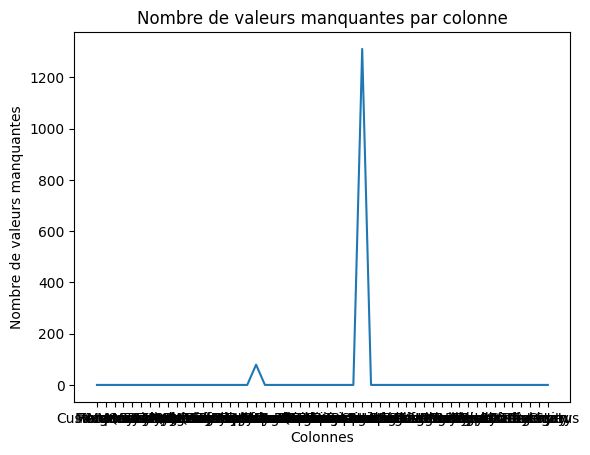

In [17]:
missing_data = data.isna().sum()
plt.plot(missing_data)
plt.title('Nombre de valeurs manquantes par colonne')
plt.xlabel('Colonnes')
plt.ylabel('Nombre de valeurs manquantes')
plt.show()

In [18]:
data["Age"].isna().sum()
# Imputation des valeurs manquantes de la colonne "Age" en utilisant KNNImputer
KNN=KNNImputer(n_neighbors=2)
data["Age"]=KNN.fit_transform(data[["Age"]])
data["Age"].isna().sum()

np.int64(0)

In [19]:
#valeurs abérantes(SupportTicketsCount)
masque_aberrant = (data["SupportTicketsCount"] < 0) | (data["SupportTicketsCount"] > 15)
data.loc[masque_aberrant, "SupportTicketsCount"] = np.nan

inputer = SimpleImputer(strategy='median')
data["SupportTicketsCount"] = inputer.fit_transform(data[["SupportTicketsCount"]])
data["SupportTicketsCount"].describe()

count    4372.000000
mean        1.968435
std         1.381120
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.000000
Name: SupportTicketsCount, dtype: float64

In [20]:
#valeurs abérantes(SatisfactionScore)
val_aberrant=data[(data["SatisfactionScore"]<1)|(data["SatisfactionScore"]>5)]
data.loc[val_aberrant.index,"SatisfactionScore"]=np.nan
data["SatisfactionScore"]=inputer.fit_transform(data[["SatisfactionScore"]])
data["SatisfactionScore"].describe()

count    4372.000000
mean        3.012580
std         1.373534
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: SatisfactionScore, dtype: float64

In [21]:
#valeurs abérantes(IpAddress)
data = data.drop('LastLoginIP', axis=1, errors='ignore')
# Parsing des formats "12/03/10", "2010-03-12"
data['RegistrationDate'] = pd.to_datetime(data['RegistrationDate'], dayfirst=True, errors='coerce')
data['RegYear'] = data['RegistrationDate'].dt.year
data['RegMonth'] = data['RegistrationDate'].dt.month
data['RegDay'] = data['RegistrationDate'].dt.day
data = data.drop('RegistrationDate', axis=1, errors='ignore')
#données inutiles
data = data.drop('NewsletterSubscribed', axis=1, errors='ignore')


C:\Users\User\AppData\Local\Temp\ipykernel_20928\2155828945.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['RegistrationDate'] = pd.to_datetime(data['RegistrationDate'], dayfirst=True, errors='coerce')


In [22]:
print(data['Churn'].value_counts(normalize=True).round(3))
print(data['AccountStatus'].value_counts(normalize=True).round(3))

# 1. Regroupement
data['AccountStatusGrouped'] = data['AccountStatus'].apply(
    lambda x: 'Active' if x == 'Active' else 'Problem'
)

# 2. Vérification du regroupement
print("=== Après regroupement ===")
print(data['AccountStatusGrouped'].value_counts())
print(data['AccountStatusGrouped'].value_counts(normalize=True).round(3))

# 3. VÉRIFICATION CRITIQUE : y a-t-il fuite de données ?
print("\n=== Churn rate par statut ORIGINAL ===")
print(pd.crosstab(data['AccountStatus'], data['Churn'], normalize='index').round(3))

print("\n=== Churn rate par statut REGROUPÉ ===")
print(pd.crosstab(data['AccountStatusGrouped'], data['Churn'], normalize='index').round(3))

Churn
0    0.667
1    0.333
Name: proportion, dtype: float64
AccountStatus
Active       0.902
Suspended    0.049
Pending      0.030
Closed       0.019
Name: proportion, dtype: float64
=== Après regroupement ===
AccountStatusGrouped
Active     3944
Problem     428
Name: count, dtype: int64
AccountStatusGrouped
Active     0.902
Problem    0.098
Name: proportion, dtype: float64

=== Churn rate par statut ORIGINAL ===
Churn              0      1
AccountStatus              
Active         0.670  0.330
Closed         0.714  0.286
Pending        0.649  0.351
Suspended      0.615  0.385

=== Churn rate par statut REGROUPÉ ===
Churn                     0      1
AccountStatusGrouped              
Active                0.670  0.330
Problem               0.645  0.355


In [23]:
col_to_drop = ['CustomerID', 'Churn']
for col in col_to_drop:
    if col in data.columns:
        data = data.drop(col, axis=1)

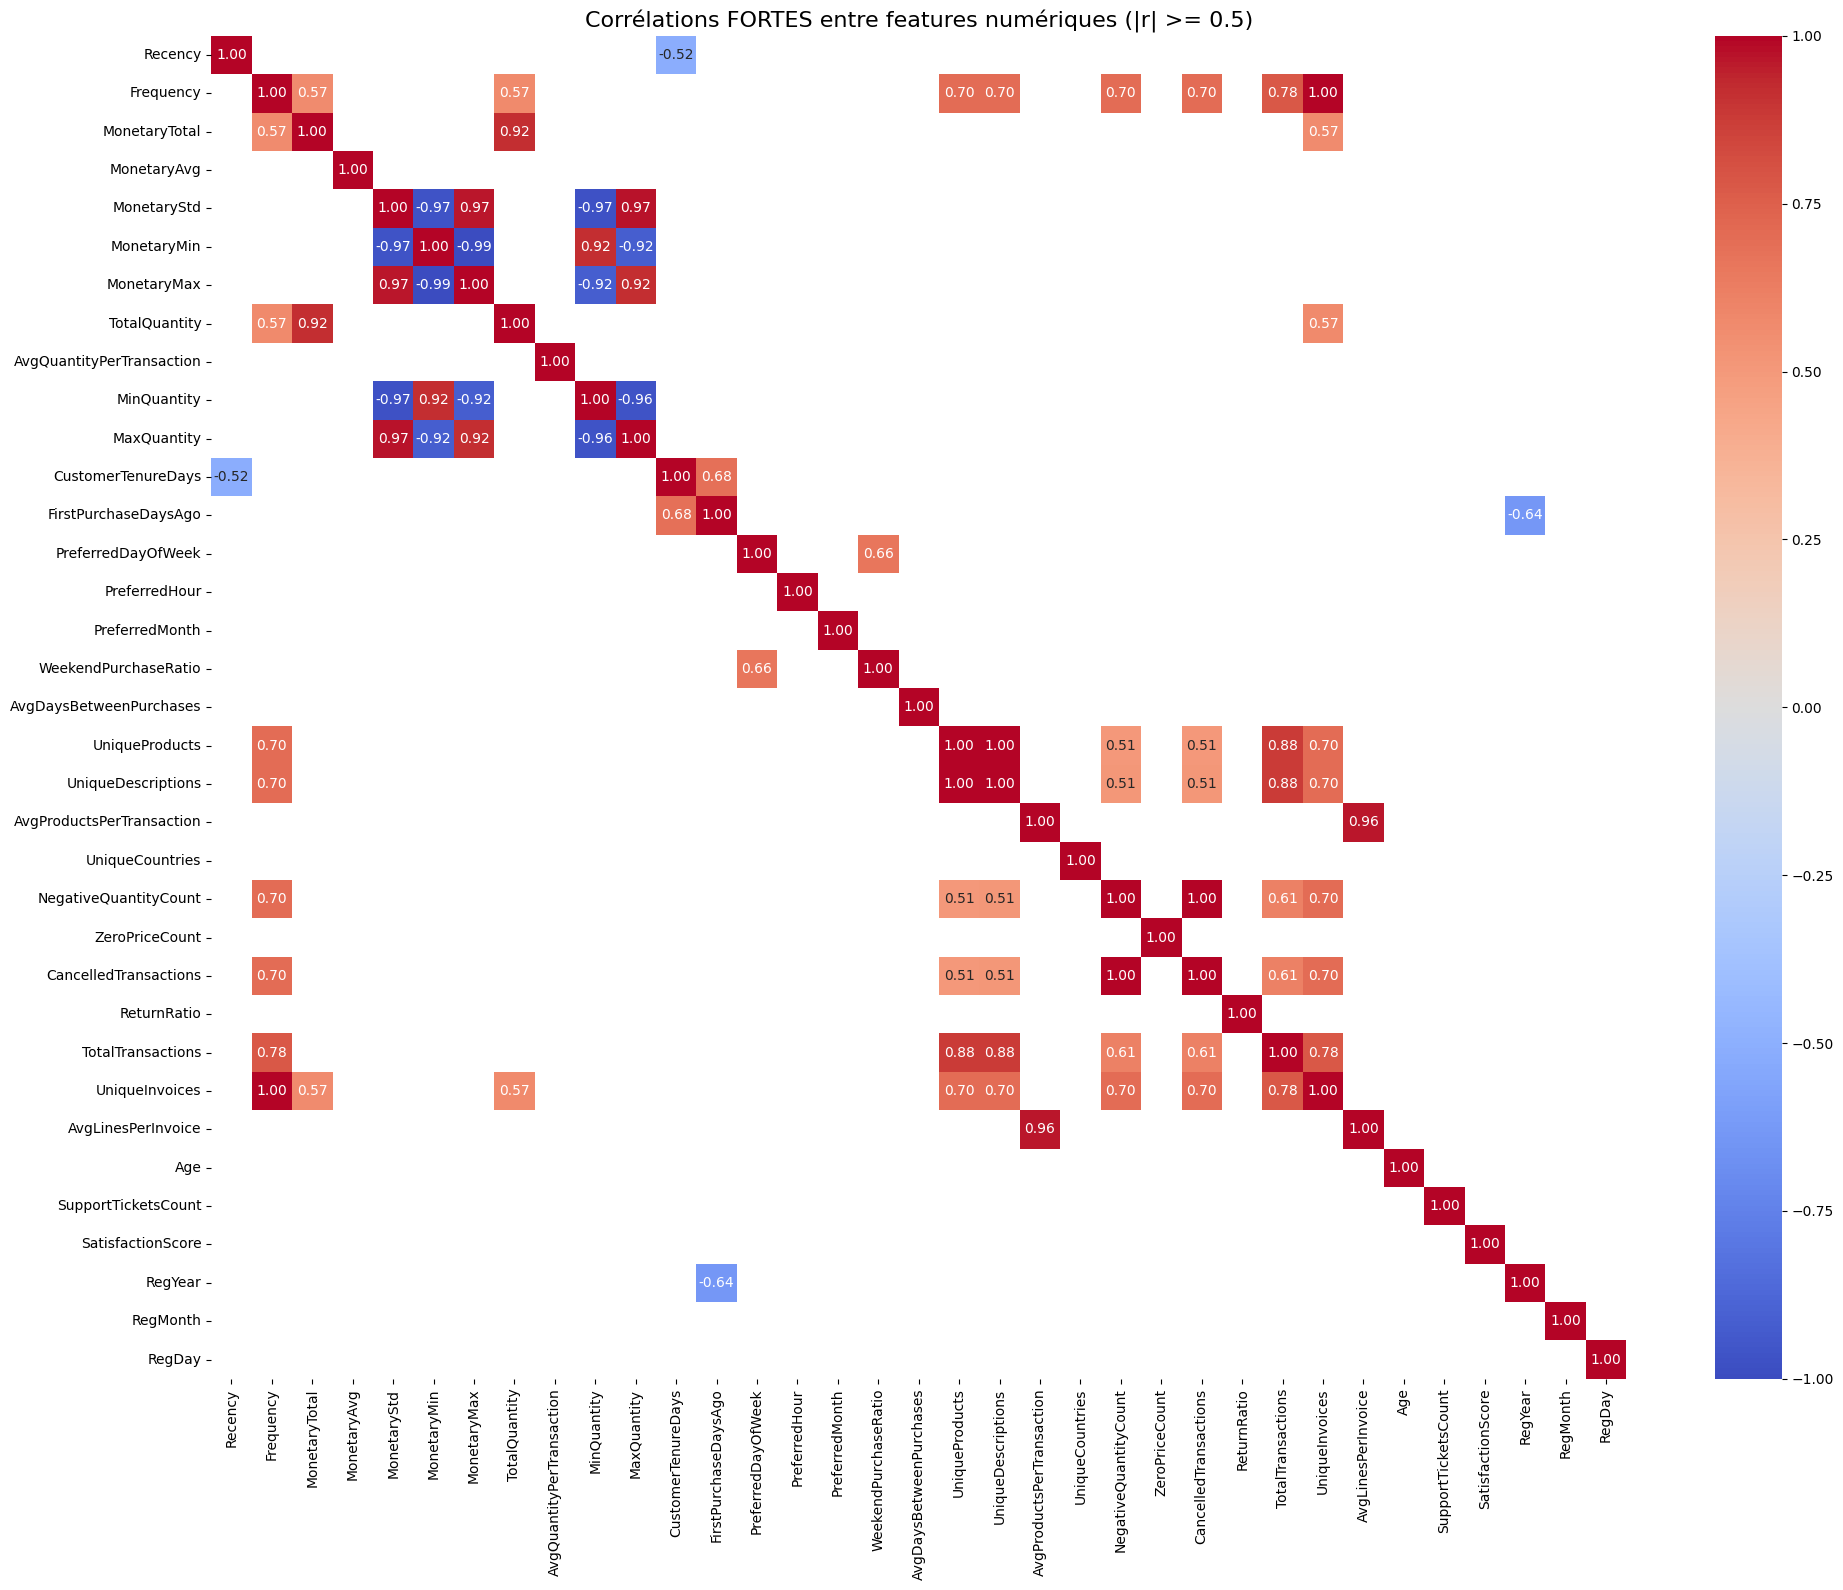

In [24]:
#MATRICE DE CORRÉLATION
# Recalculer les colonnes numériques à partir de l'état actuel de `data`
num_cols = data.select_dtypes(include=np.number).columns.tolist()

# Matrice de corrélation robuste (évite les colonnes supprimées comme CustomerID/Churn)
corr_matrix = data[num_cols].corr()

# HEATMAP (seulement les fortes corrélations pour la lisibilité)
plt.figure(figsize=(20, 16))
mask = (np.abs(corr_matrix) < 0.5) & (np.abs(corr_matrix) > 0)  # Masque les faibles
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Corrélations FORTES entre features numériques (|r| >= 0.5)', fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
#DÉTECTION DES PAIRES REDONDANTES (|r| > 0.8)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))
            print(f"{corr_matrix.columns[i]} <-> {corr_matrix.columns[j]} : {val:.3f}")

if not high_corr:
    print("Aucune paire trouvée au-dessus de 0.8")

Frequency <-> UniqueInvoices : 1.000
MonetaryTotal <-> TotalQuantity : 0.922
MonetaryStd <-> MonetaryMin : -0.967
MonetaryStd <-> MonetaryMax : 0.966
MonetaryStd <-> MinQuantity : -0.974
MonetaryStd <-> MaxQuantity : 0.973
MonetaryMin <-> MonetaryMax : -0.994
MonetaryMin <-> MinQuantity : 0.919
MonetaryMin <-> MaxQuantity : -0.916
MonetaryMax <-> MinQuantity : -0.916
MonetaryMax <-> MaxQuantity : 0.921
MinQuantity <-> MaxQuantity : -0.961
UniqueProducts <-> UniqueDescriptions : 1.000
UniqueProducts <-> TotalTransactions : 0.878
UniqueDescriptions <-> TotalTransactions : 0.880
AvgProductsPerTransaction <-> AvgLinesPerInvoice : 0.963
NegativeQuantityCount <-> CancelledTransactions : 1.000


In [27]:
# VIF (Variance Inflation Factor)
# VIF > 10 = multicolinéarité sévère
print("\n=== VIF (Variance Inflation Factor) ===")

vif_data = pd.DataFrame()
vif_data["Feature"] = num_cols
X_vif = data[num_cols].replace([np.inf, -np.inf], np.nan).astype(float).dropna()
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data.head(15))


=== VIF (Variance Inflation Factor) ===


c:\Users\User\Desktop\MLproject\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                  Feature           VIF
1               Frequency           inf
27         UniqueInvoices           inf
24  CancelledTransactions           inf
22  NegativeQuantityCount           inf
12   FirstPurchaseDaysAgo  3.264285e+05
11     CustomerTenureDays  1.813847e+05
0                 Recency  8.937388e+04
19     UniqueDescriptions  1.573386e+04
18         UniqueProducts  1.550819e+04
32                RegYear  6.124961e+02
21        UniqueCountries  5.488183e+02
6             MonetaryMax  3.808725e+02
5             MonetaryMin  3.802042e+02
10            MaxQuantity  1.220135e+02
9             MinQuantity  1.074631e+02


In [ ]:
#SUPPRESSION DES COLONNES REDONDANTES
cols_to_drop = [
    'UniqueInvoices',           
    'NegativeQuantityCount',    
    'UniqueDescriptions',       
    
    'MonetaryMin',              
    'MonetaryMax',              
    'MinQuantity',              
    'MaxQuantity',              
    
    'TotalQuantity',            
    'TotalTransactions',        
    'AvgLinesPerInvoice', 
    
    'FirstPurchaseDaysAgo',     
    'CustomerTenureDays',       
]

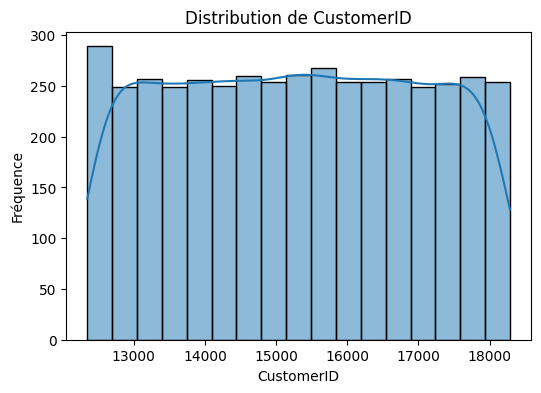

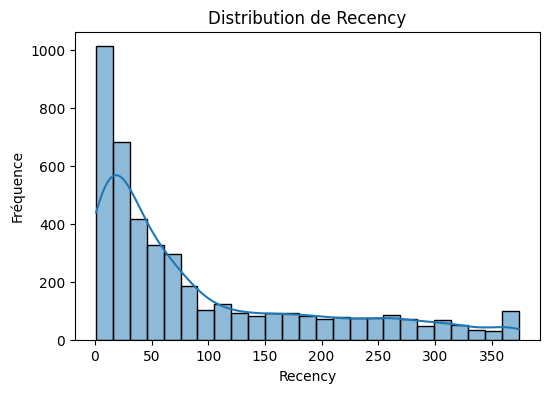

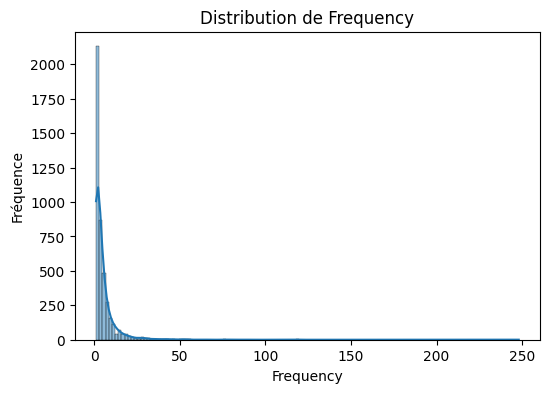

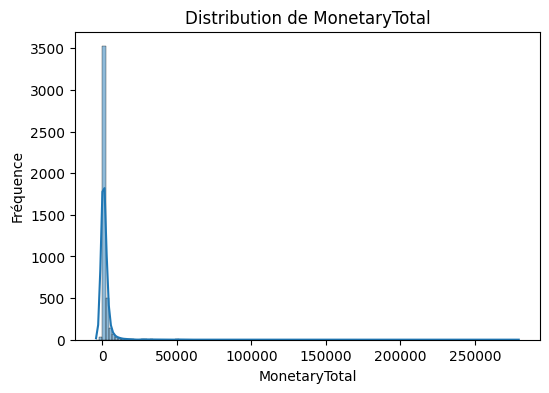

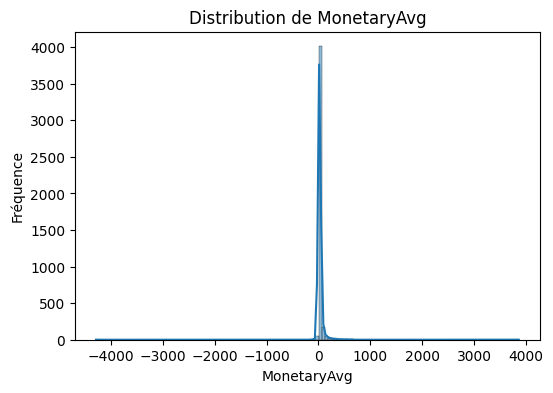

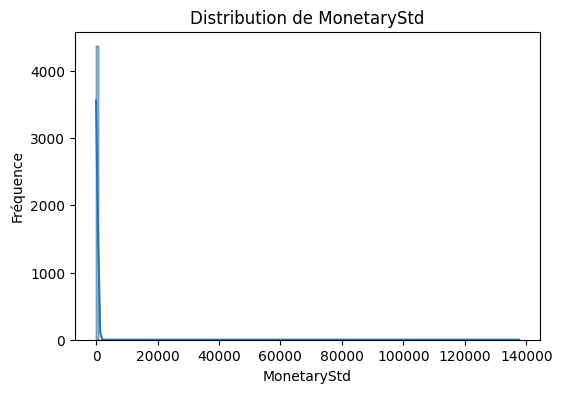

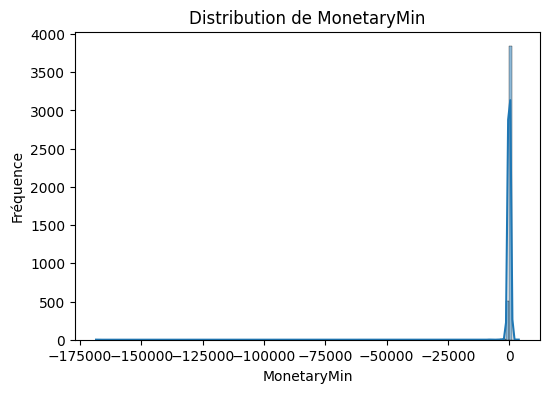

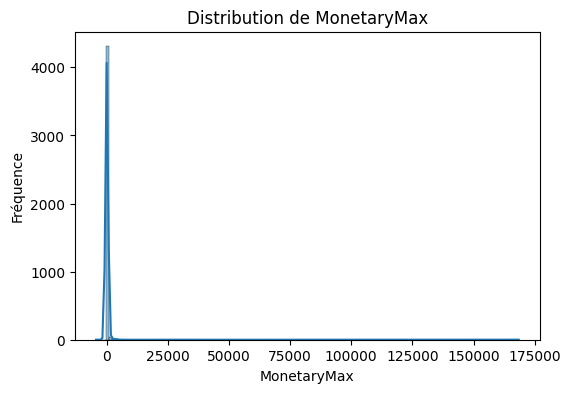

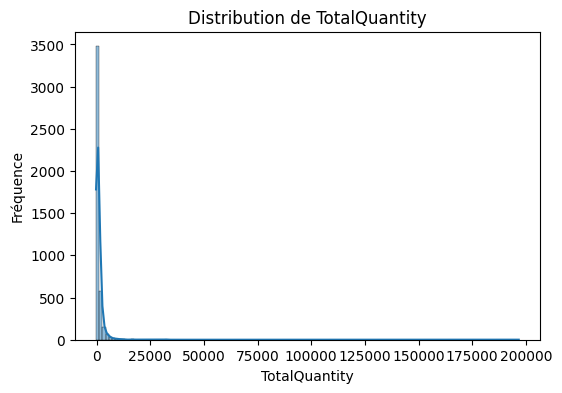

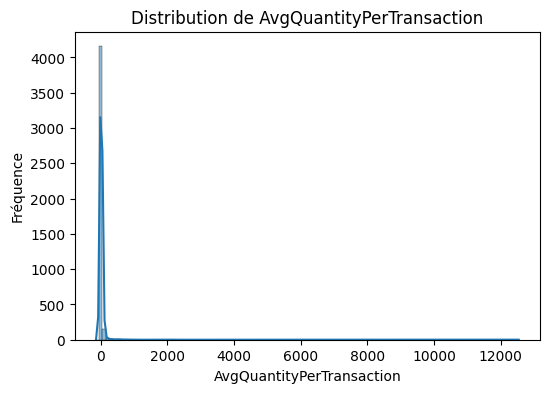

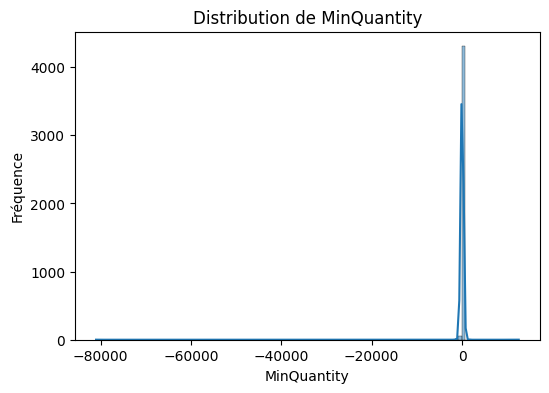

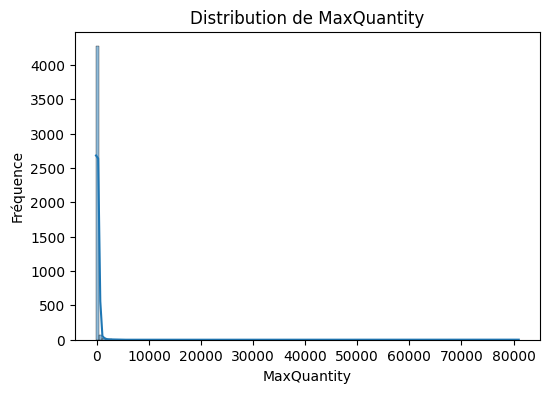

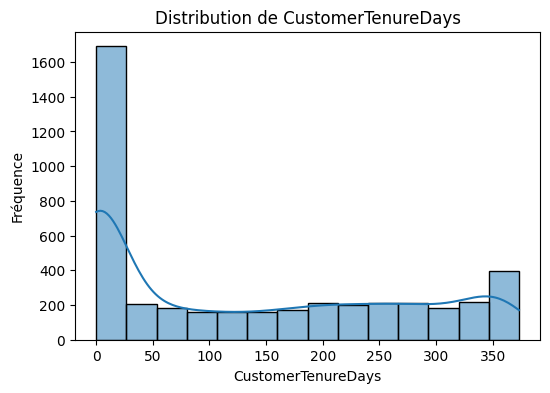

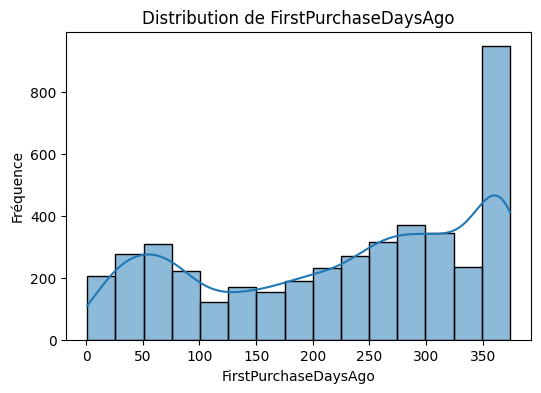

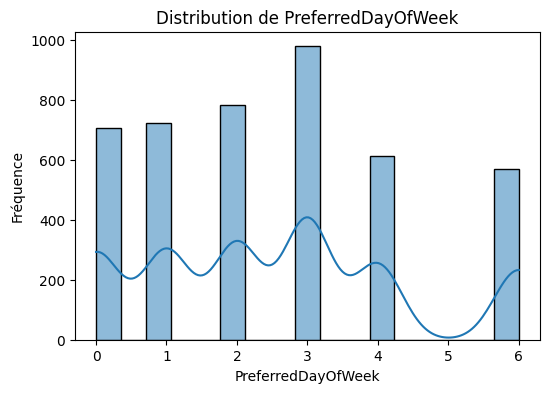

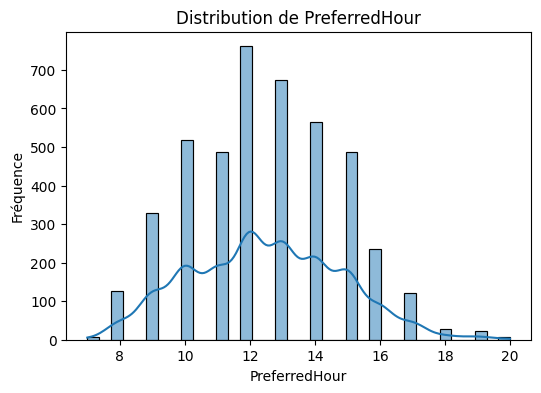

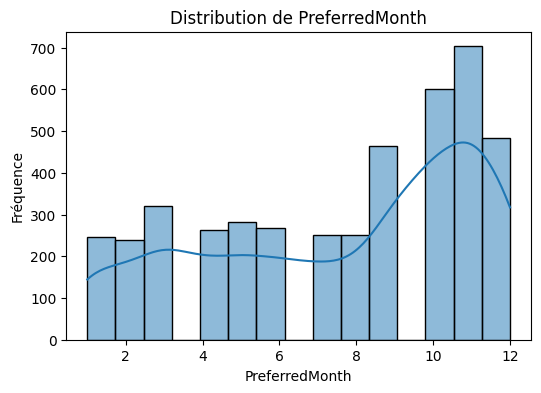

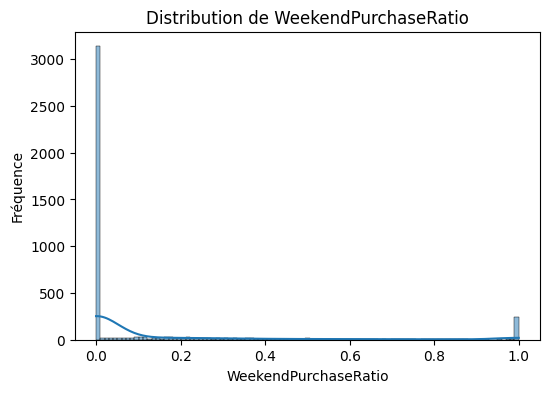

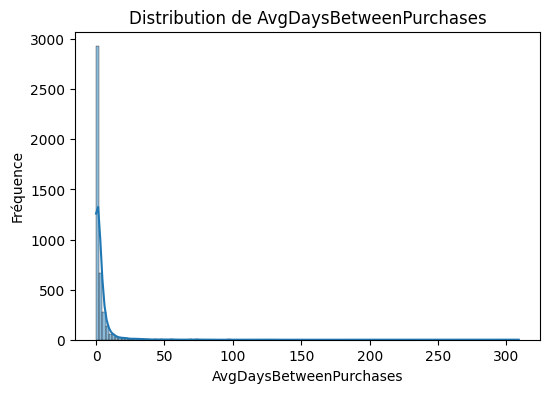

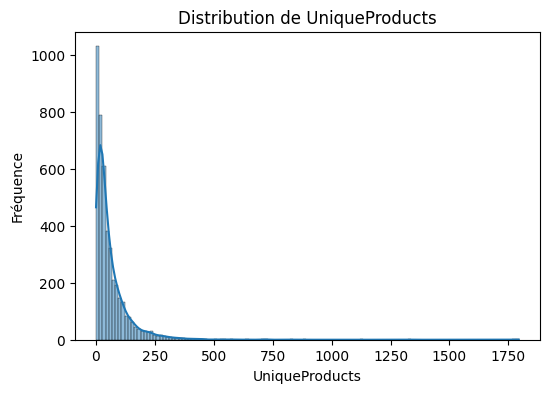

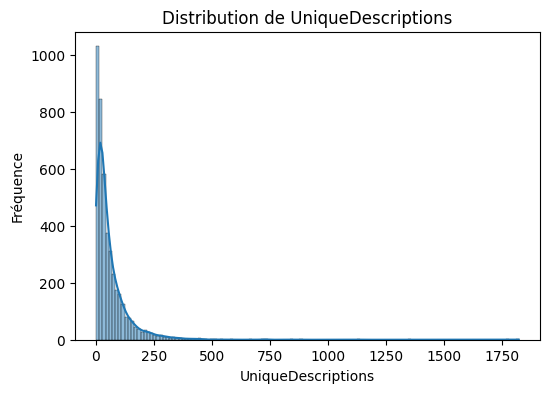

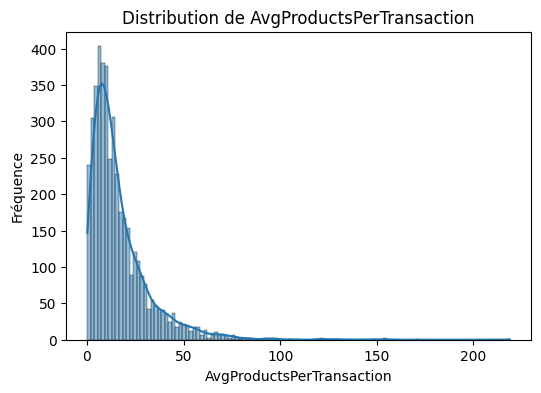

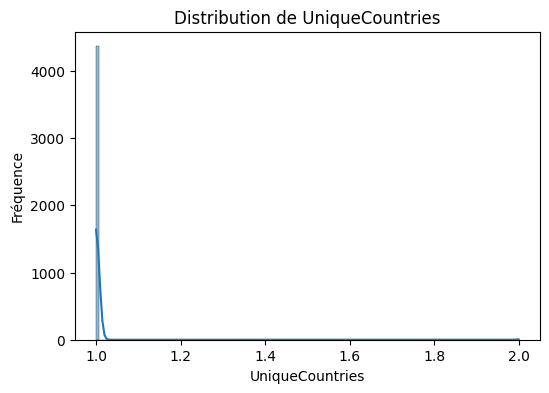

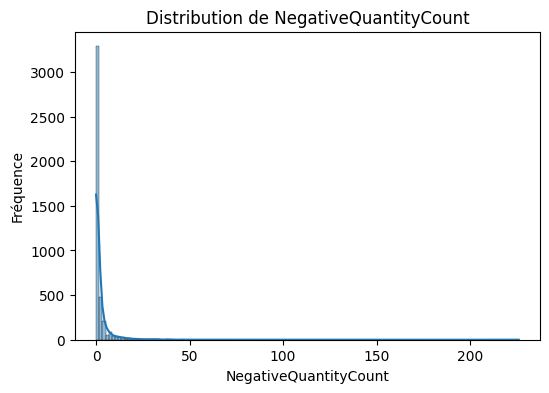

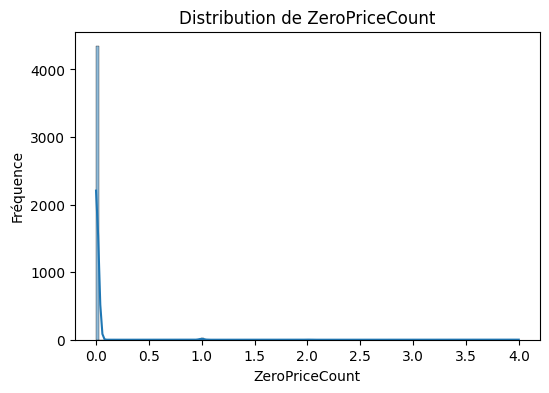

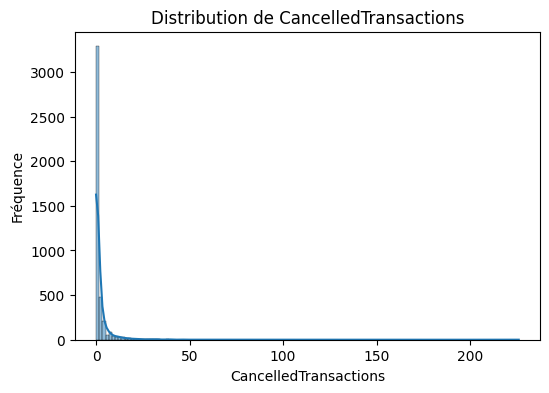

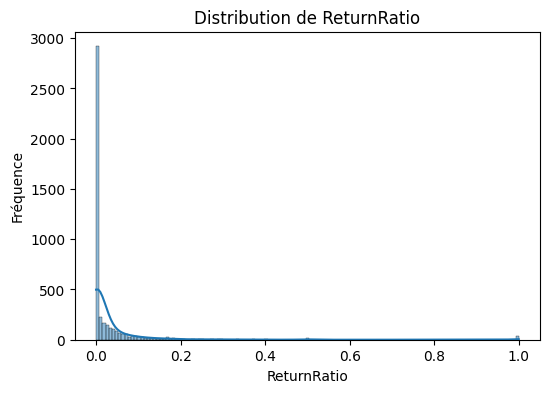

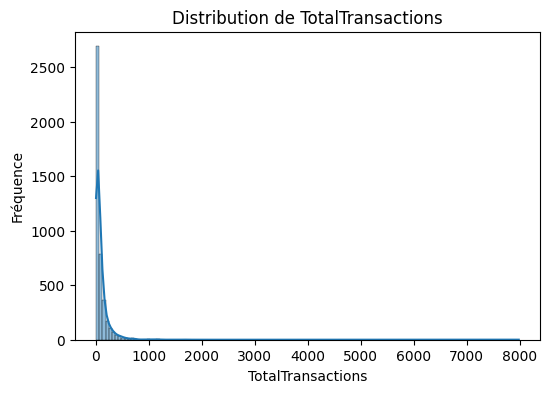

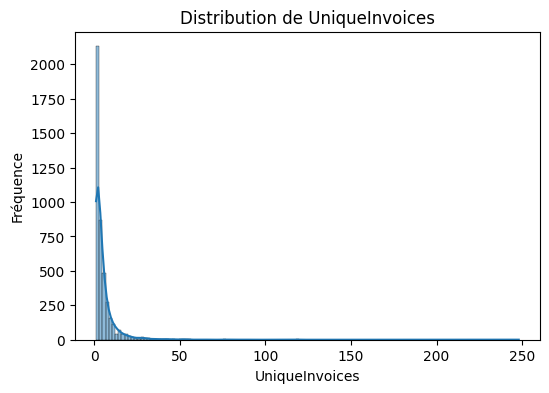

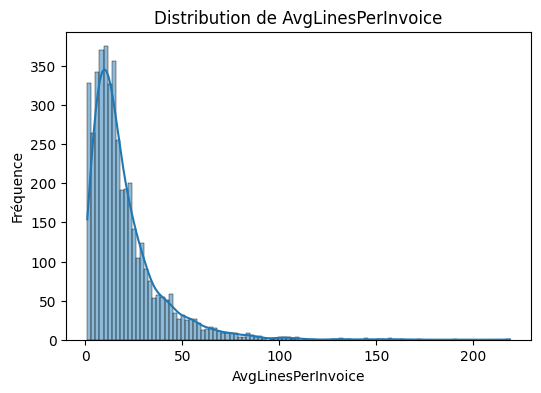

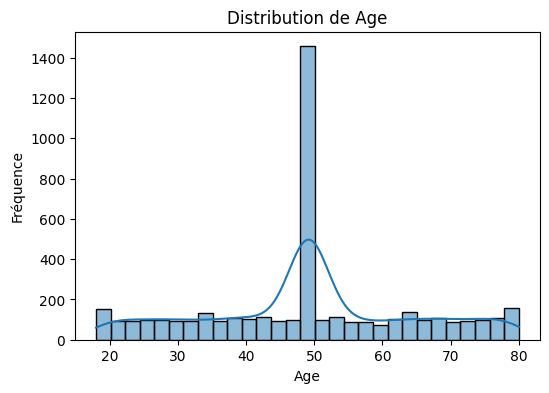

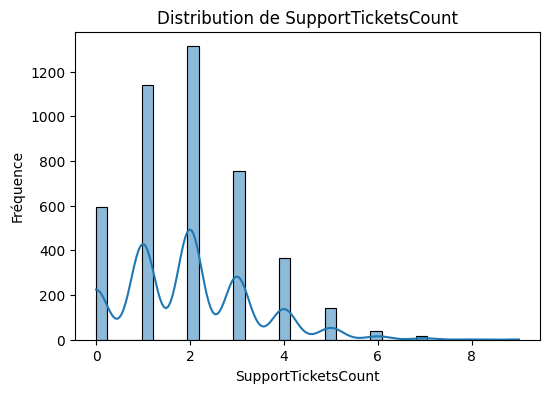

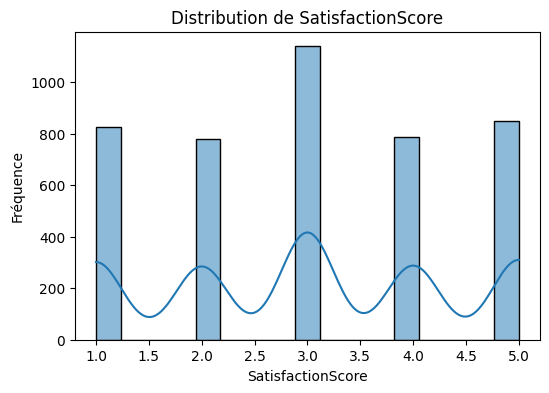

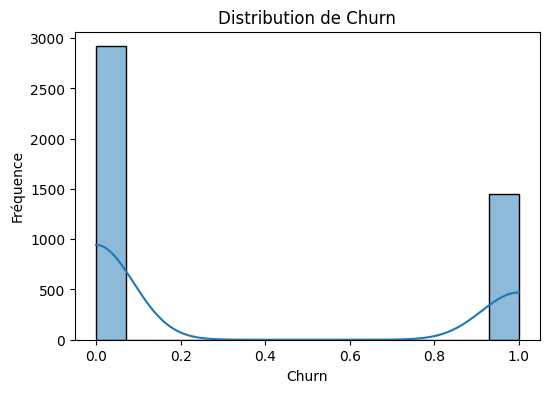

In [82]:
#Numériques : Age, AnnualIncome, SupportTicketsCount, SatisfactionScore
num_cols=data.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.show()

In [83]:
#verifier le pic d'age 50 ans
pic_50 = (data['Age'] == 50).sum()
print(f"Nombre de clients âgés de 50 ans : {pic_50}")

Nombre de clients âgés de 50 ans : 58


C:\Users\User\AppData\Local\Temp\ipykernel_4100\1818900129.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=data.select_dtypes(include='object').columns


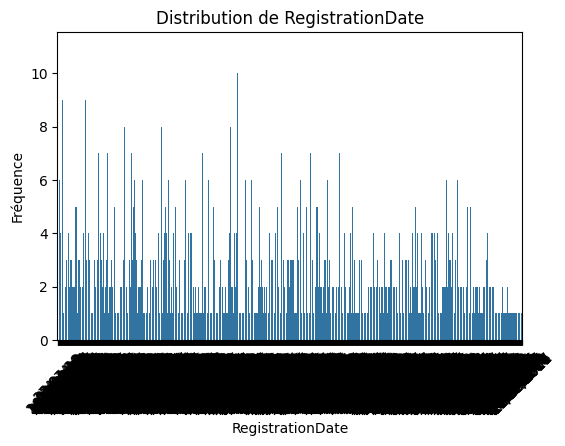

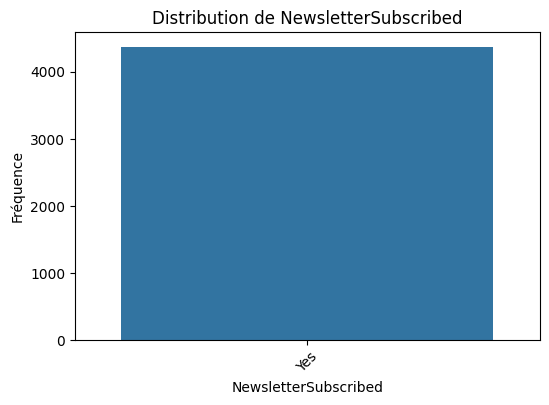

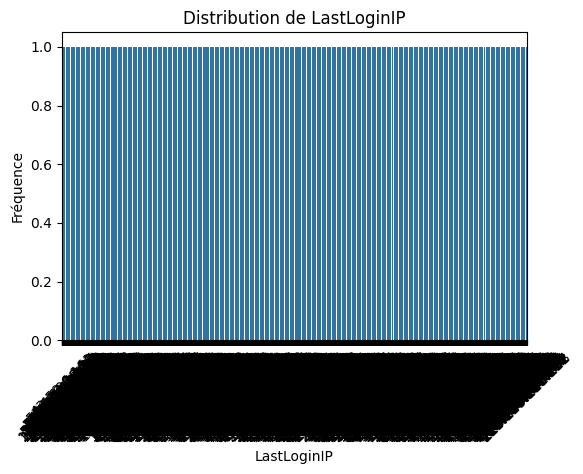

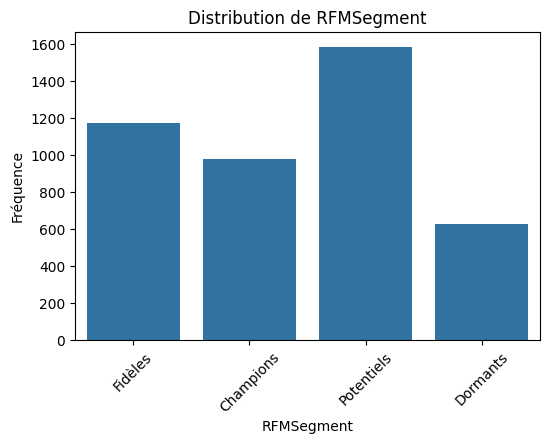

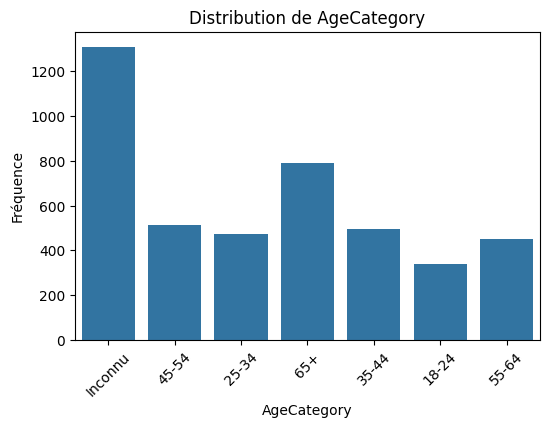

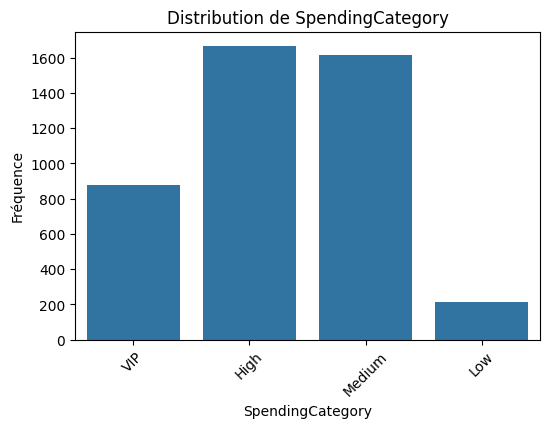

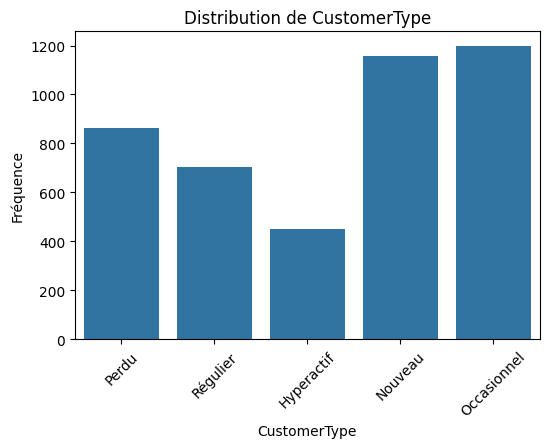

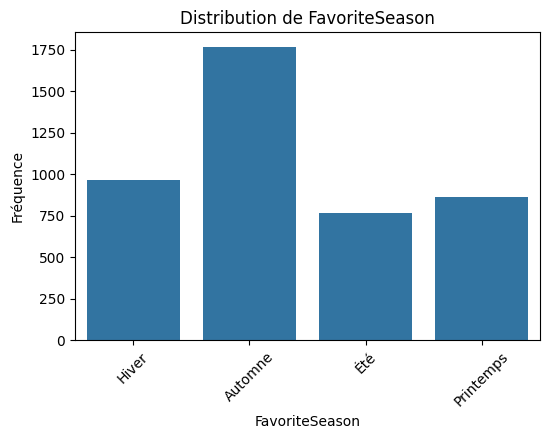

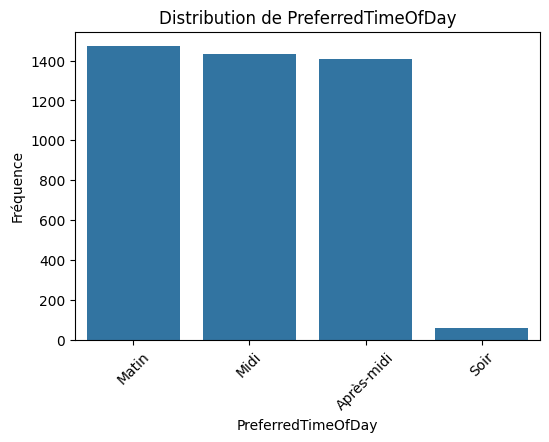

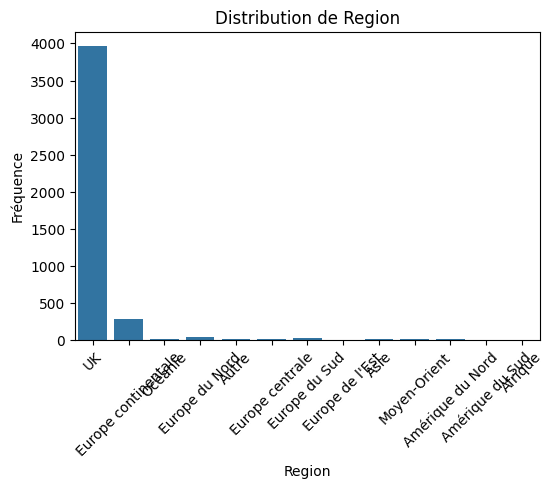

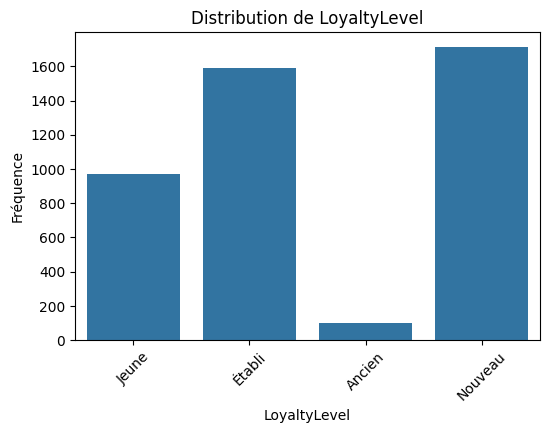

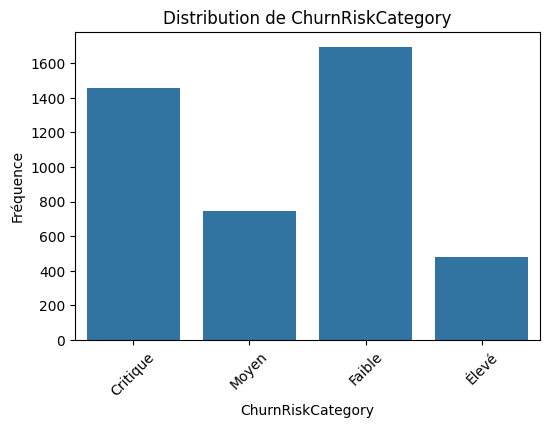

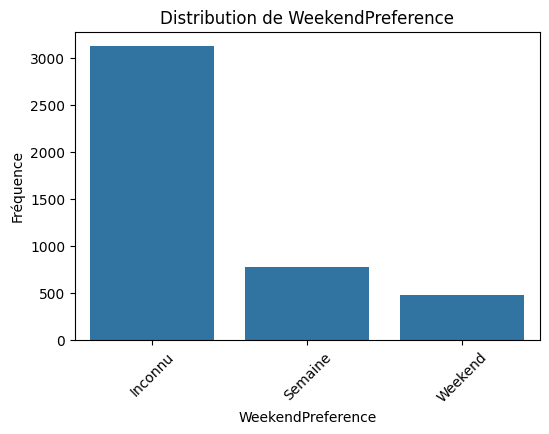

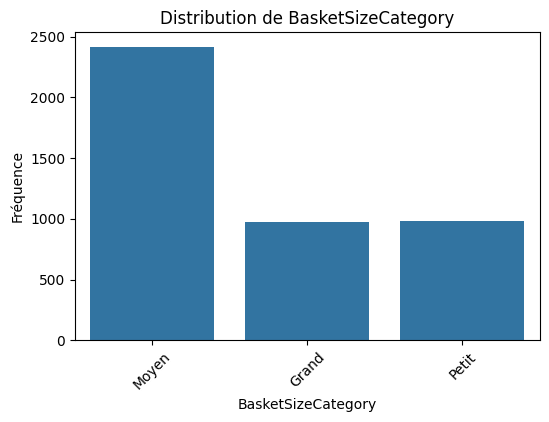

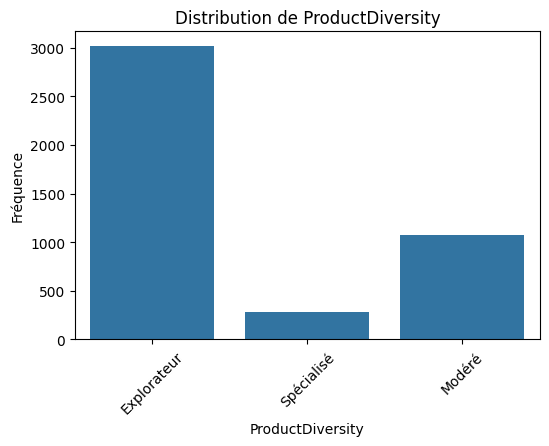

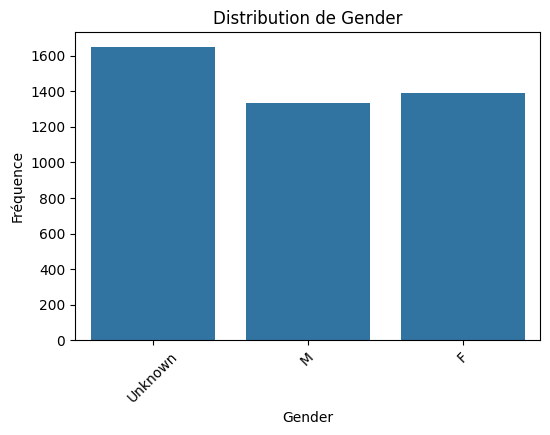

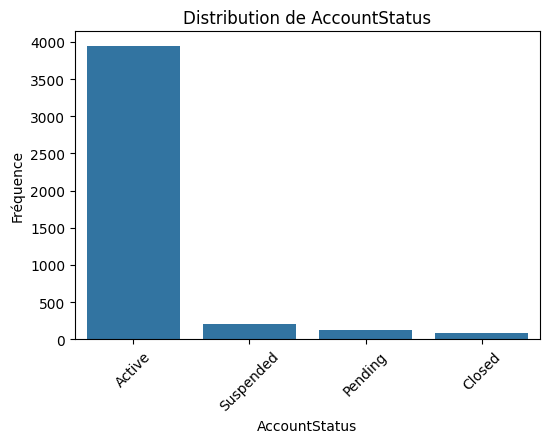

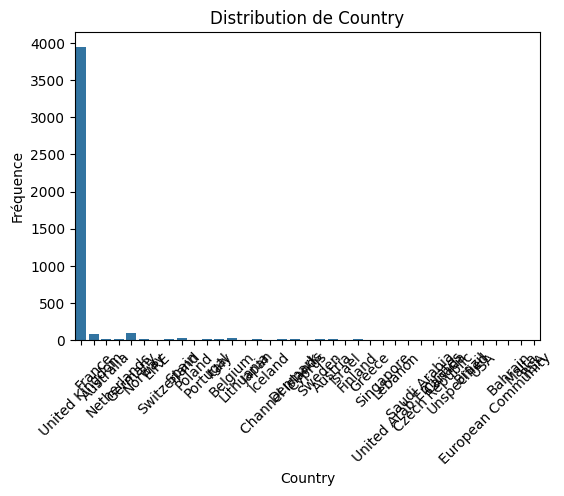

In [84]:
#catégoriques :
cat_cols=data.select_dtypes(include='object').columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=data, x=col)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.xticks(rotation=45)
    plt.show()

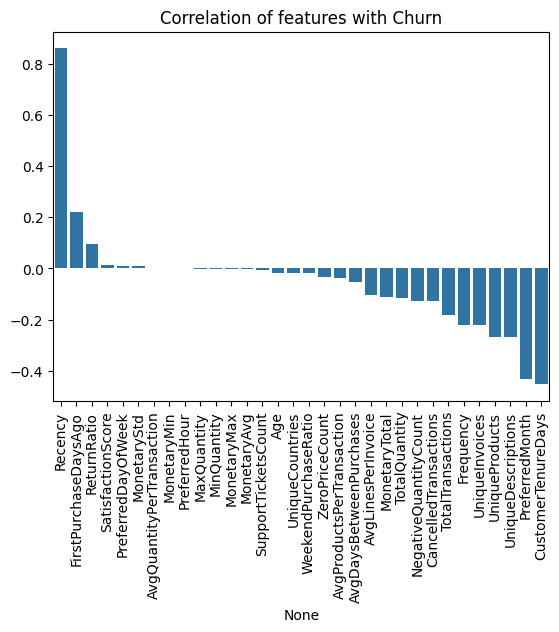

In [77]:
num_cols=data.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('CustomerID')
num_cols.remove('Churn')
#features correlation
corr=data[num_cols].corrwith(data['Churn']).sort_values(ascending=False)
sns.barplot(x=corr.index,y=corr.values)
plt.xticks(rotation=90)
plt.title('Correlation of features with Churn')
plt.show()